### Install & Authenticate Earth Engine

In [1]:
# Install Earth Engine
!pip install -q earthengine-api geemap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.2 MB/s eta 0:00:00


In [24]:
import ee
import geemap
import matplotlib.pyplot as plt

In [3]:
# Authenticate
ee.Authenticate()

# Initialize
ee.Initialize(project='ee-deepalibidwai')


### Load ROI

In [15]:
# Load ROI FeatureCollection
roi = ee.FeatureCollection("projects/ee-deepalibidwai/assets/Riyadh_governate")
roi_geom = roi.geometry()



### Dynamic World Rural/UrbMask (2020–2024 Summer)

In [16]:
# Load Dynamic World
dw = (
    ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
    .select("label")
    .filterDate("2020-07-01", "2024-09-30")
    .filterBounds(roi)
    .filter(ee.Filter.calendarRange(7, 9, "month"))  # July–September
    .mode()
)

# Masks
urban_mask_dw = dw.eq(6)        # Urban
non_urban_mask_dw = dw.neq(6)   # Not urban
bare_ground_mask = dw.neq(7)    # Not bare ground

final_rural_mask = non_urban_mask_dw.And(bare_ground_mask)


### Define Rural Reference Geometry

In [17]:
rural_buffer_distance = 30000  # 30 km

rural_area_candidate = roi_geom.buffer(rural_buffer_distance)
rural_reference_geometry = rural_area_candidate.difference(roi_geom)


### Function to Compute UHI for a Given Year

In [18]:
def compute_uhi(year):
    year = int(year)
    start = ee.Date.fromYMD(year, 7, 1)
    end = ee.Date.fromYMD(year, 9, 30)

    # Load Landsat 8 Collection 2 L2
    landsat = (
        ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
        .filterBounds(roi_geom)
        .filterDate(start, end)
        .filter(ee.Filter.lt("CLOUD_COVER", 10))
        .map(lambda img: convert_lst(img))
    )

    lst = landsat.median()

    # Urban LST
    urban = lst.updateMask(urban_mask_dw)
    mean_urban = (
        urban.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=roi_geom,
            scale=100,
            maxPixels=1e13,
        )
        .get("ST_Celsius")
    )

    # Rural LST
    rural = lst.updateMask(final_rural_mask).clip(rural_reference_geometry)
    mean_rural = (
        rural.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=rural_reference_geometry,
            scale=100,
            maxPixels=1e13,
        )
        .get("ST_Celsius")
    )

    # UHI = Urban - Rural
    uhi_intensity = ee.Number(mean_urban).subtract(mean_rural)

    # Spatial UHI map
    uhi_image = lst.subtract(ee.Image.constant(mean_rural)).rename("UHI_Spatial")

    return (
        uhi_image.set("year", year)
        .set("Mean_Urban", mean_urban)
        .set("Mean_Rural", mean_rural)
        .set("UHI_Intensity", uhi_intensity)
    )


### Helper Function for LST Conversion

In [19]:
def convert_lst(img):
    gain = ee.Number(img.get("TEMPERATURE_MULT_BAND_ST_B10"))
    offset = ee.Number(img.get("TEMPERATURE_ADD_BAND_ST_B10"))
    lst_c = (
        img.select("ST_B10")
        .multiply(gain)
        .add(offset)
        .subtract(273.15)  # Kelvin → Celsius
        .rename("ST_Celsius")
    )
    return lst_c.copyProperties(img, img.propertyNames())


### Process for Selected Years

In [20]:
years = [2020, 2024]
uhi_images = [compute_uhi(y) for y in years]

uhi_col = ee.ImageCollection(uhi_images)


### Print Summary Values

In [21]:
print("Years:", uhi_col.aggregate_array("year").getInfo())
print("Mean Urban LSTs:", uhi_col.aggregate_array("Mean_Urban").getInfo())
print("Mean Rural LSTs:", uhi_col.aggregate_array("Mean_Rural").getInfo())
print("UHI Intensities:", uhi_col.aggregate_array("UHI_Intensity").getInfo())


Years: [2020, 2024]
Mean Urban LSTs: [51.09607926210944, 51.073707253337645]
Mean Rural LSTs: [50.18540573446051, 50.52785289873202]
UHI Intensities: [0.9106735276489317, 0.5458543546056234]


### Visualize using geemap

In [22]:
Map = geemap.Map(center=[24.7, 46.7], zoom=9)

vis_params = {
    "min": -5,
    "max": 5,
    "palette": ["blue", "white", "red"],
}

uhi2020 = uhi_col.filter(ee.Filter.eq("year", 2020)).first().clip(roi_geom)
uhi2024 = uhi_col.filter(ee.Filter.eq("year", 2024)).first().clip(roi_geom)

Map.addLayer(uhi2020, vis_params, "UHI 2020")
Map.addLayer(uhi2024, vis_params, "UHI 2024")

Map


Map(center=[24.7, 46.7], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(…

### Export Images to Google Drive

##### Export 2020 RGB visualization

In [ ]:
uhi2020_vis = uhi2020.visualize(**vis_params).clip(roi_geom)

task1 = ee.batch.Export.image.toDrive(
    image=uhi2020_vis,
    description="UHI_2020_Riyadh_RGB",
    folder="EarthEngineExports",
    fileNamePrefix="UHI_2020_Riyadh_RGB",
    region=roi_geom,
    scale=100,
    crs="EPSG:4326",
    maxPixels=1e13,
)
task1.start()


##### Export 2024 UHI raster

In [ ]:
task2 = ee.batch.Export.image.toDrive(
    image=uhi2024,
    description="UHI_2024_Riyadh",
    folder="EarthEngineExports",
    fileNamePrefix="UHI_2024_Riyadh",
    region=roi_geom,
    scale=100,
    crs="EPSG:4326",
    maxPixels=1e13,
)
task2.start()


### Extract UHI time-series values from Earth Engine

In [23]:
# Extract values to Python lists
years_list = uhi_col.aggregate_array("year").getInfo()
urban_list = uhi_col.aggregate_array("Mean_Urban").getInfo()
rural_list = uhi_col.aggregate_array("Mean_Rural").getInfo()
uhi_list   = uhi_col.aggregate_array("UHI_Intensity").getInfo()

years_list, urban_list, rural_list, uhi_list


([2020, 2024],
 [51.09607926210944, 51.073707253337645],
 [50.18540573446051, 50.52785289873202],
 [0.9106735276489317, 0.5458543546056234])

##### Urban vs Rural LST (°C) plot

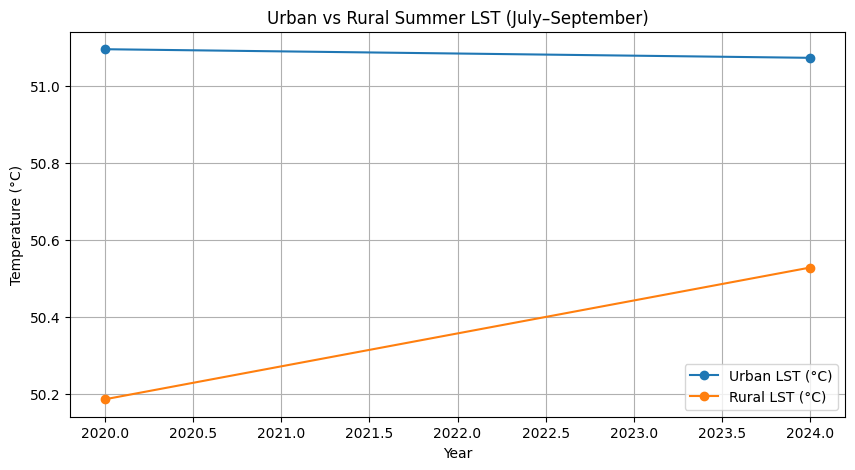

In [25]:

plt.figure(figsize=(10,5))
plt.plot(years_list, urban_list, marker='o', label='Urban LST (°C)')
plt.plot(years_list, rural_list, marker='o', label='Rural LST (°C)')

plt.title("Urban vs Rural Summer LST (July–September)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.legend()
plt.show()


##### UHI Intensity (Urban – Rural) plot

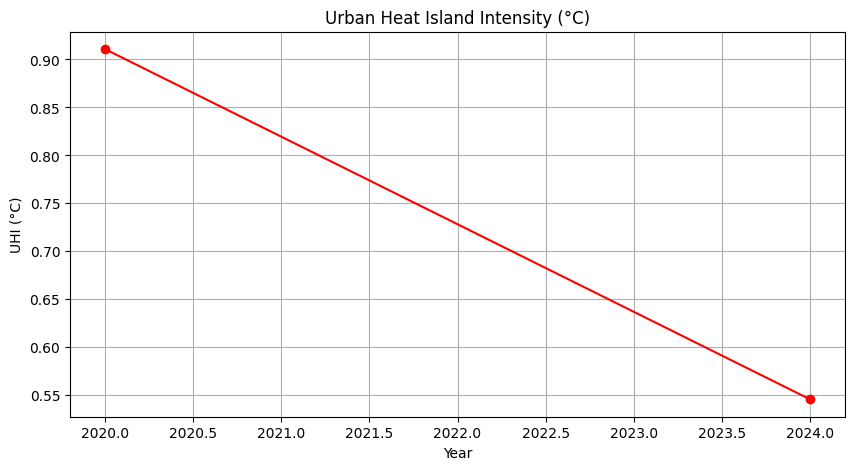

In [26]:
plt.figure(figsize=(10,5))
plt.plot(years_list, uhi_list, marker='o', color='red')

plt.title("Urban Heat Island Intensity (°C)")
plt.xlabel("Year")
plt.ylabel("UHI (°C)")
plt.grid(True)
plt.show()
